In [16]:
import pandas as pd
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import pandas_datareader.data as web
from datetime import datetime
import statsmodels.api as sm

In [2]:
portfolio_tickers = [
    "AAAU", "ACM", "CIBR", "IBIT", "ITA", "OSK", "RGLD", "SGDM",
    "USO", "USXF", "XHE"
]
dfs = []
for ticker in portfolio_tickers:
    df_tmp = yf.Ticker(ticker)
    # Download historical price data
    historical_data = df_tmp.history(period="max", interval="1d")
    historical_data['ticker'] = ticker
    # Display the first few rows
    dfs.append(historical_data)

print(len(dfs))
dfs[0].head()

11


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,ticker
Date,,,,,,,,,
2018-08-15 00:00:00-04:00,11.84,11.84,11.74,11.74,27300,0.0,0.0,0.0,AAAU
2018-08-16 00:00:00-04:00,11.78,11.80,11.74,11.74,428400,0.0,0.0,0.0,AAAU
2018-08-17 00:00:00-04:00,11.80,11.82,11.77,11.82,52400,0.0,0.0,0.0,AAAU
2018-08-20 00:00:00-04:00,11.88,11.91,11.85,11.90,28700,0.0,0.0,0.0,AAAU
2018-08-21 00:00:00-04:00,11.92,11.95,11.89,11.93,30600,0.0,0.0,0.0,AAAU


In [7]:
for df in dfs:
    df_tmp = df.reset_index()
    print(f"{df_tmp['ticker'].unique()[0]}: {df_tmp['Date'].min()}")

AAAU: 2018-08-15 00:00:00-04:00
ACM: 2007-05-10 00:00:00-04:00
CIBR: 2015-07-07 00:00:00-04:00
IBIT: 2024-01-11 00:00:00-05:00
ITA: 2006-05-05 00:00:00-04:00
OSK: 1985-10-02 00:00:00-04:00
RGLD: 1981-06-09 00:00:00-04:00
SGDM: 2014-07-15 00:00:00-04:00
USO: 2006-04-10 00:00:00-04:00
USXF: 2020-06-18 00:00:00-04:00
XHE: 2011-01-27 00:00:00-05:00


In [8]:
# get the log returns for each dataframe
def get_log_returns(df_name: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    get the log returns for a specific column
    """
    df_name['log_returns'] = np.log(df_name[col]) - np.log(df_name[col].shift(1))
    return df_name

dfs = [get_log_returns(df_name=df, col="Close") for df in dfs]
dfs[0].head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,ticker,log_returns
Date,,,,,,,,,,
2018-08-15 00:00:00-04:00,11.84,11.84,11.74,11.74,27300,0.0,0.0,0.0,AAAU,NaN
2018-08-16 00:00:00-04:00,11.78,11.80,11.74,11.74,428400,0.0,0.0,0.0,AAAU,0.000000
2018-08-17 00:00:00-04:00,11.80,11.82,11.77,11.82,52400,0.0,0.0,0.0,AAAU,0.006791
2018-08-20 00:00:00-04:00,11.88,11.91,11.85,11.90,28700,0.0,0.0,0.0,AAAU,0.006745
2018-08-21 00:00:00-04:00,11.92,11.95,11.89,11.93,30600,0.0,0.0,0.0,AAAU,0.002518


In [10]:
# merge all the dataframes together
df_log_returns = None
for df in dfs:
    df[f"log_returns_{df['ticker'].unique()[0]}"] = df[f"log_returns"]
    if df_log_returns is None:
        df_log_returns = df[f"log_returns_{df['ticker'].unique()[0]}"]
    else:
        # merge the df
        df_log_returns = pd.merge(df_log_returns, df[f"log_returns_{df['ticker'].unique()[0]}"], how="inner", left_index=True, right_index=True)

print(df_log_returns.head())
print(df_log_returns.tail())

                           log_returns_AAAU  log_returns_ACM  \
Date                                                           
2024-01-11 00:00:00-05:00          0.001994         0.002571   
2024-01-12 00:00:00-05:00          0.009911         0.010552   
2024-01-16 00:00:00-05:00         -0.009413        -0.018736   
2024-01-17 00:00:00-05:00         -0.011011        -0.016115   
2024-01-18 00:00:00-05:00          0.008020         0.011828   

                           log_returns_CIBR  log_returns_IBIT  \
Date                                                            
2024-01-11 00:00:00-05:00          0.011021               NaN   
2024-01-12 00:00:00-05:00          0.006555         -0.064363   
2024-01-16 00:00:00-05:00         -0.004001         -0.010062   
2024-01-17 00:00:00-05:00         -0.008969         -0.012620   
2024-01-18 00:00:00-05:00          0.012062         -0.044824   

                           log_returns_ITA  log_returns_OSK  log_returns_RGLD  \
Date          

In [11]:
df_log_returns.shape

(382, 11)

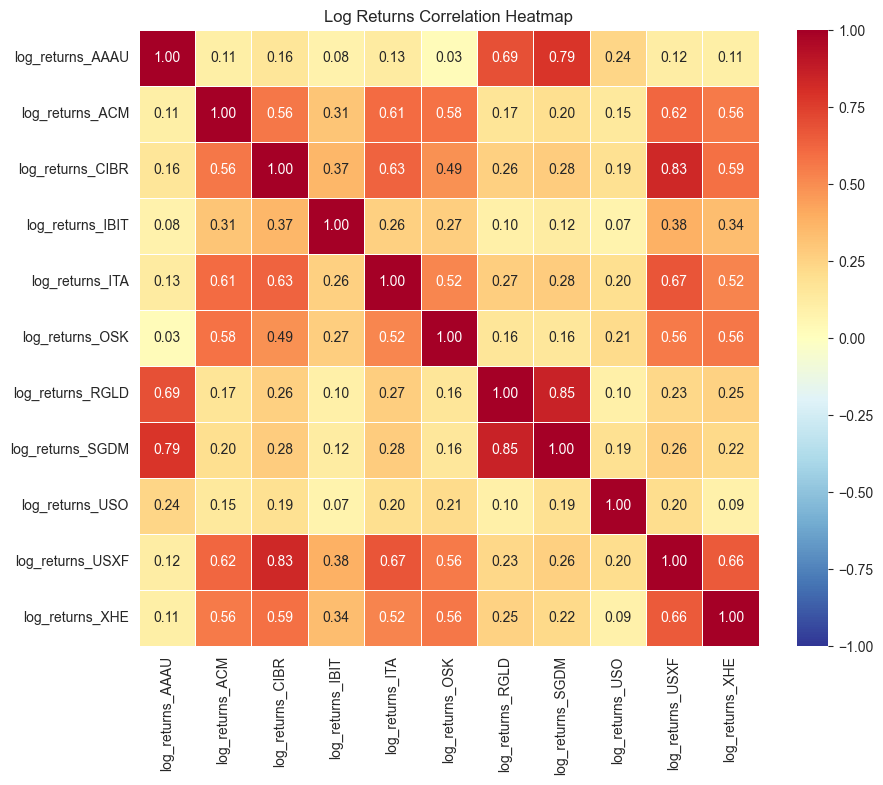

In [12]:
corr = df_log_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="RdYlBu_r",     # Diverging blue-red palette for readability
    vmin=-1,
    vmax=1,
    annot=True,          # Show correlation coefficients in each cell
    fmt=".2f",           # Format values to 2 decimal places
    linewidths=0.5
)
plt.title("Log Returns Correlation Heatmap")
plt.show()

In [23]:
# Define the start and end date for pulling data 2024-01-11
start = datetime(2024, 1, 1)
end = datetime(2025, 7, 22)

# Define the FRED series symbols and descriptions
fred_series = {
    'FDEFX': 'Defense_Expenditures_Quarterly',
    'G160071A027NBEA': 'Defense_Expenditures_Annual',
    'A824RE1Q156NBEA': 'Defense_Spending_GDP_Ratio',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'EFFR': 'Effective_Fed_Funds_Rate_Daily',
    'CPIAUCSL': 'CPI_All_Items',
    'CPILFESL': 'CPI_Core',
    'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
    'GEPUCURRENT': 'Global_EPU_Index',
    'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
    'DFII10': '10_Year_TIPS_Yield',
    'DGS10': '10_Year_Treasury_Yield',
    'DTWEXBGS': 'Dollar_Index',
    'DCOILWTICO': 'Crude_Oil_Price_WTI',
    'DGS2': '2_Year_Treasury_Yield',
    'DGS5': '5_Year_Treasury_Yield',
    'W824RC1A027NBEA': 'Medicare_transfer_receipts',
    'W729RC1': 'Medicaid_transfer_receipts',
    'CPIMEDSL': 'CPI_Medical_Care',
    'WPUSIHCARE2': 'PPI_Medicaid_Patient_services',
    'OOPMFSOAEE416211': 'Medicaid_FFS',
    'HHCSMFSOAE46216': 'Medicaid_home_health_payments',
    'WTISPLC': 'WTI_Spot_price',
    'INDPRO': 'Industrial_Production',
    'IPMAN': 'Manufacturing_Production',
    'CBBTCUSD': 'Bitcoin_spot_price',
    'M2SL': 'Money_supply'

}

# Pull data from FRED and store in a dictionary
data = {}
for symbol, label in fred_series.items():
    try:
        data[label] = web.DataReader(symbol, 'fred', start, end)
    except Exception as e:
        print(f"Failed to fetch {label} ({symbol}): {e}")
df_all = pd.concat(data.values(), axis=1)
df_all.columns = data.keys()

In [18]:
df_all.head()

,Defense_Expenditures_Quarterly,Defense_Expenditures_Annual,Defense_Spending_GDP_Ratio,Fed_Funds_Rate,Effective_Fed_Funds_Rate_Daily,CPI_All_Items,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,Real_10-Year_Yield,...,Medicaid_transfer_receipts,CPI_Medical_Care,PPI_Medicaid_Patient_services,Medicaid_FFS,Medicaid_home_health_payments,WTI_Spot_price,Industrial_Production,Manufacturing_Production,Bitcoin_spot_price,Money_supply
DATE,,,,,,,,,,,,,,,,,,,,,
2024-01-11,NaN,NaN,NaN,NaN,5.33,NaN,NaN,57.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46324.98,NaN
2024-01-12,NaN,NaN,NaN,NaN,5.33,NaN,NaN,76.85,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42797.41,NaN
2024-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.97,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42829.80,NaN
2024-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.89,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41715.82,NaN
2024-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42500.00,NaN


In [22]:
df_all['Defense_Spending_GDP_Ratio'].dropna()

DATE
2024-04-01    3.6
2024-07-01    3.7
2024-10-01    3.7
2025-01-01    3.7
Name: Defense_Spending_GDP_Ratio, dtype: float64